# ⭐ Day 4: Lists, Tuples, Sets & Dictionaries Mastery | Core Data Structures for AI & ML | Step-by-Step Tutorial with Examples & Exercises


Welcome to Day 4 of your 369-day journey to AI mastery! Today we explore Python's four foundational collection types: **lists**, **tuples**, **sets**, and **dictionaries**. These aren't just abstract data structures—they are the very fabric of every machine learning pipeline you'll ever build. When you load a dataset of 50,000 images, you're storing them in a **list** of arrays. When you define the shape of a neural network layer, you're using a **tuple** like `(224, 224, 3)` for image dimensions. When preprocessing text for natural language processing, you use **sets** to extract unique vocabulary and eliminate duplicates. When configuring your model's hyperparameters or encoding categorical features, you rely on **dictionaries** to map keys to values with O(1) lookup speed.

Understanding these collections deeply is non-negotiable for AI practitioners. Lists provide ordered, mutable sequences perfect for training batches and loss history tracking. Tuples offer immutable, hashable structures ideal for fixed configurations and dictionary keys. Sets deliver blazing-fast membership testing—critical when filtering stopwords from millions of text samples or finding unique users in recommendation systems. Dictionaries serve as the universal container for feature mappings, label encodings, JSON API responses, and model weight storage. Together, these four types form the backbone of data manipulation in Python's scientific ecosystem.

By the end of today, you'll master not just the syntax, but the **patterns** that appear constantly in ML workflows: list comprehensions for feature engineering, tuple unpacking for returning multiple values from data splits, set operations for train/test validation, and dictionary comprehensions for rapid data transformation. You'll understand when to choose each type based on mutability needs, lookup speed, and memory constraints—decisions that matter when processing gigabyte-scale datasets.

This is Day 4 of your structured 369-day path. We're building the data handling skills that will enable you to manipulate tensors, construct data pipelines, and preprocess raw information into ML-ready formats. Whether you're preparing image batches for computer vision, tokenizing text for transformers, or managing experiment configurations, these collections are your daily tools. Let's dive deep into Python's most powerful built-in data structures and unlock the patterns that professional data scientists use every single day!


## Table of Contents

1. [Lists: Ordered & Mutable Collections](#lists-ordered--mutable-collections)
2. [List Comprehensions & Advanced Patterns](#list-comprehensions--advanced-patterns)
3. [Tuples: Immutable & Hashable](#tuples-immutable--hashable)
4. [Sets: Unique & Fast](#sets-unique--fast)
5. [Dictionaries: Key-Value Mappings](#dictionaries-key-value-mappings)
6. [Iteration Patterns for ML](#iteration-patterns-for-ml)
7. [Real-World ML Patterns](#real-world-ml-patterns)
8. [🛠️ Hands-On Exercises](#hands-on-exercises)
9. [Solutions](#solutions)


## Lists: Ordered & Mutable Collections


Lists are Python's most versatile sequence type—ordered, mutable, and capable of storing mixed data types. In AI/ML, lists are everywhere: batches of training samples, sequences of loss values during training, lists of feature names, and paths to image files. Understanding list operations deeply is essential because you'll perform these operations millions of times when preprocessing data.

Let's start with creation, indexing, and the most common methods you'll use daily. Lists support zero-based indexing (like arrays in other languages) and negative indexing to access elements from the end. Slicing with `[start:stop:step]` creates sublists without modifying the original—a pattern used constantly when splitting datasets into chunks or creating validation folds.



In [1]:
# Creating and basic operations
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
train_losses = [0.89, 0.76, 0.65, 0.58, 0.52, 0.48, 0.45]

# Indexing and slicing
print(f"First feature: {feature_names[0]}")
print(f"Last 3 features: {feature_names[-3:]}")
print(f"All but last: {feature_names[:-1]}")
print(f"Every other loss: {train_losses[::2]}")

# Common ML methods: tracking metrics
epochs_completed = []
for epoch in range(5):
    epochs_completed.append(epoch)  # Add to end
    
print(f"Epochs tracked: {epochs_completed}")

# Extend vs Append: building batches
batch_1 = [0.1, 0.2, 0.3]
batch_2 = [0.4, 0.5, 0.6]
batch_1.extend(batch_2)  # Adds elements individually
print(f"Extended batch: {batch_1}")

# Insert and remove: managing feature lists
feature_names.insert(2, 'petal_area')  # Insert at index 2
print(f"After insertion: {feature_names}")
feature_names.remove('petal_area')  # Remove by value
print(f"After removal: {feature_names}")

# Sort and reverse: analyzing results
scores = [0.82, 0.91, 0.78, 0.95, 0.88]
scores.sort(reverse=True)  # In-place sort, descending
print(f"Ranked scores: {scores}")

First feature: sepal_length
Last 3 features: ['petal_length', 'petal_width', 'species']
All but last: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Every other loss: [0.89, 0.65, 0.52, 0.45]
Epochs tracked: [0, 1, 2, 3, 4]
Extended batch: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
After insertion: ['sepal_length', 'sepal_width', 'petal_area', 'petal_length', 'petal_width', 'species']
After removal: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Ranked scores: [0.95, 0.91, 0.88, 0.82, 0.78]


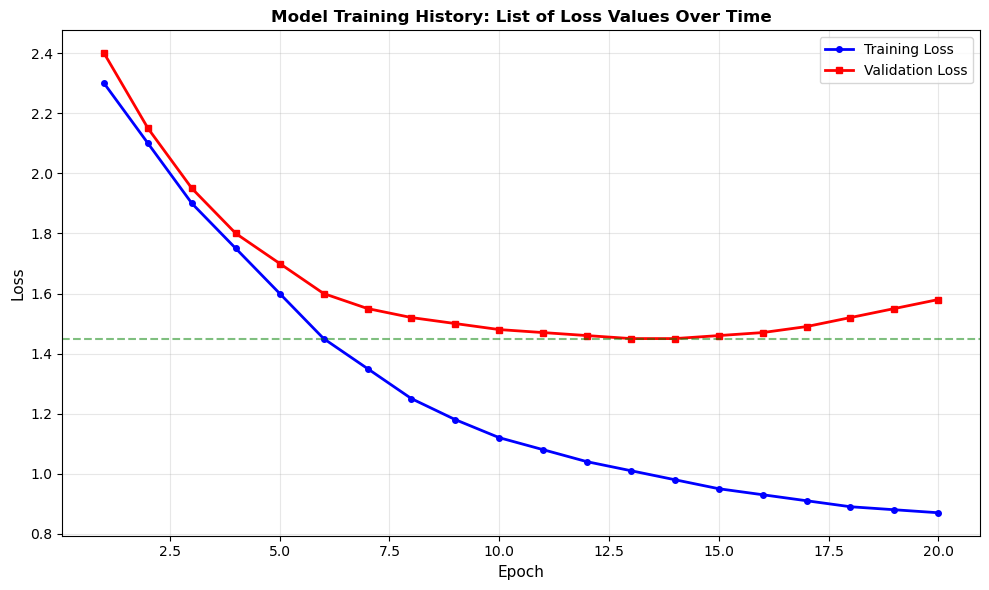

Best validation epoch: 13
Final training loss: 0.870


In [2]:
import matplotlib.pyplot as plt

# Simulated training history
epochs = list(range(1, 21))
train_loss = [2.3, 2.1, 1.9, 1.75, 1.6, 1.45, 1.35, 1.25, 1.18, 1.12,
              1.08, 1.04, 1.01, 0.98, 0.95, 0.93, 0.91, 0.89, 0.88, 0.87]
val_loss = [2.4, 2.15, 1.95, 1.8, 1.7, 1.6, 1.55, 1.52, 1.5, 1.48,
            1.47, 1.46, 1.45, 1.45, 1.46, 1.47, 1.49, 1.52, 1.55, 1.58]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Model Training History: List of Loss Values Over Time', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=min(val_loss), color='g', linestyle='--', alpha=0.5, label=f'Best val: {min(val_loss):.3f}')
plt.tight_layout()
plt.show()

print(f"Best validation epoch: {val_loss.index(min(val_loss)) + 1}")
print(f"Final training loss: {train_loss[-1]:.3f}")

### List Comprehensions & Advanced Patterns


List comprehensions provide a concise, readable way to create lists from existing iterables. In AI/ML, they're essential for feature engineering, data cleaning, and transforming batches. A comprehension `[expression for item in iterable if condition]` is often faster and clearer than equivalent `for` loops.

Mastering comprehensions means writing cleaner preprocessing pipelines. You'll use them to normalize features, filter outliers, flatten nested data structures, and generate synthetic training data. The optional `if` clause filters elements, while nested comprehensions handle multi-dimensional data.



In [3]:
# Basic comprehension: normalize pixel values from 0-255 to 0-1
raw_pixels = [0, 64, 128, 192, 255]
normalized = [p / 255.0 for p in raw_pixels]
print(f"Normalized pixels: {normalized}")

# With condition: filter high-confidence predictions
confidences = [0.45, 0.89, 0.92, 0.34, 0.76, 0.91]
high_conf = [c for c in confidences if c > 0.8]
print(f"High confidence ({len(high_conf)} items): {high_conf}")

# Nested comprehension: flatten a batch of image patches
# Imagine 3 images, each split into 2x2 patches
batch_patches = [
    [[1, 2], [3, 4]],      # Image 1 patches
    [[5, 6], [7, 8]],      # Image 2 patches  
    [[9, 10], [11, 12]]    # Image 3 patches
]
flattened = [pixel for image in batch_patches for row in image for pixel in row]
print(f"Flattened batch: {flattened}")

# Dictionary-like feature extraction using enumerate
sensor_readings = [23.5, 24.1, 22.8, 25.2]
indexed_readings = [(i, val) for i, val in enumerate(sensor_readings)]
print(f"Indexed: {indexed_readings}")

# Multiple conditions: select valid training samples
labels = ['cat', 'dog', 'cat', 'unknown', 'dog', 'cat']
confidences = [0.9, 0.3, 0.95, 0.1, 0.85, 0.92]
# Keep only 'cat' or 'dog' with confidence > 0.8
valid_samples = [label for label, conf in zip(labels, confidences) 
                 if label in ['cat', 'dog'] and conf > 0.8]
print(f"Valid training samples: {valid_samples}")

Normalized pixels: [0.0, 0.25098039215686274, 0.5019607843137255, 0.7529411764705882, 1.0]
High confidence (3 items): [0.89, 0.92, 0.91]
Flattened batch: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Indexed: [(0, 23.5), (1, 24.1), (2, 22.8), (3, 25.2)]
Valid training samples: ['cat', 'cat', 'dog', 'cat']


## Tuples: Immutable & Hashable


Tuples are immutable sequences—once created, they cannot be modified. This immutability makes them perfect for fixed data like image dimensions, coordinate points, or hyperparameter configurations that shouldn't change during execution. In ML, tuples are also **hashable**, meaning they can be used as dictionary keys or stored in sets—impossible with lists.

The immutability guarantee prevents bugs where accidental modification corrupts your data pipeline. When you see a tuple, you know it's constant. This is why function arguments are often tuples (fixed inputs) while return values might be lists (variable results).



In [4]:
# Creating tuples: parentheses optional but recommended for clarity
image_shape = (224, 224, 3)  # Height, width, channels
batch_size = 32
hyperparams = (0.001, 0.9, 0.999)  # LR, beta1, beta2 for Adam

# Single element gotcha: needs trailing comma!
not_a_tuple = (42)  # Just an integer!
is_a_tuple = (42,)  # Actually a tuple
print(f"Type of not_a_tuple: {type(not_a_tuple)}")
print(f"Type of is_a_tuple: {type(is_a_tuple)}")

# Tuple unpacking: multiple assignment
learning_rate, beta1, beta2 = hyperparams
print(f"Adam config: lr={learning_rate}, b1={beta1}, b2={beta2}")

# Unpacking in loops: iterating over paired data
coordinates = [(0, 0), (1, 0), (0, 1), (1, 1)]
print("Bounding box corners:")
for x, y in coordinates:
    print(f"  Point: ({x}, {y})")

# Extended unpacking (Python 3+)
results = (0.92, 0.88, 0.85, 0.91, 0.87)  # 5-fold CV scores
best, *middle, worst = results
print(f"Best fold: {best}, Worst fold: {worst}, Middle: {middle}")

# Tuples as dictionary keys: counting image patches by position
patch_counts = {}
positions = [(0, 0), (0, 1), (1, 0), (1, 1), (0, 0), (0, 0)]
for pos in positions:
    patch_counts[pos] = patch_counts.get(pos, 0) + 1
print(f"Patch frequency by position: {patch_counts}")

Type of not_a_tuple: <class 'int'>
Type of is_a_tuple: <class 'tuple'>
Adam config: lr=0.001, b1=0.9, b2=0.999
Bounding box corners:
  Point: (0, 0)
  Point: (1, 0)
  Point: (0, 1)
  Point: (1, 1)
Best fold: 0.92, Worst fold: 0.87, Middle: [0.88, 0.85, 0.91]
Patch frequency by position: {(0, 0): 3, (0, 1): 1, (1, 0): 1, (1, 1): 1}


## Sets: Unique & Fast


Sets are unordered collections of unique elements with O(1) membership testing. In AI/ML, sets are invaluable for: extracting unique vocabulary from text corpora, finding common users between train/test splits (data leakage detection), removing duplicate samples, and fast lookup of stopwords or allowed labels.

Unlike lists, sets automatically eliminate duplicates. Unlike dictionaries, they only store keys (no values). The mathematical set operations (union, intersection, difference) translate directly to data operations you'll perform daily.



In [5]:
# Creating sets from lists (automatic deduplication)
raw_tokens = ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the']
unique_tokens = set(raw_tokens)
print(f"Unique tokens ({len(unique_tokens)}): {unique_tokens}")

# Set operations: finding data leakage between splits
train_users = {'user_1', 'user_2', 'user_3', 'user_4', 'user_5'}
test_users = {'user_4', 'user_5', 'user_6', 'user_7'}

# Intersection: users in both sets (potential leakage!)
overlap = train_users & test_users
print(f"Data leakage risk: {overlap}")

# Difference: users only in test (acceptable)
test_only = test_users - train_users
print(f"Test-only users: {test_only}")

# Symmetric difference: users in exactly one set
unique_to_either = train_users ^ test_users
print(f"Unique to either split: {unique_to_either}")

# Union: all unique users
all_users = train_users | test_users
print(f"Total unique users: {len(all_users)}")

# Practical ML: fast stopword removal
stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were'}
text_tokens = ['the', 'model', 'is', 'trained', 'on', 'a', 'gpu']
filtered = [t for t in text_tokens if t not in stopwords]
print(f"After stopword removal: {filtered}")

# Set methods: building vocabulary incrementally
vocab = set()
vocab.update(['neural', 'network'])  # Add multiple items
vocab.add('deep')  # Add single item
vocab.discard('rnn')  # Remove if exists (no error if missing)
vocab.remove('network')  # Remove (raises KeyError if missing)
print(f"Current vocabulary: {vocab}")

Unique tokens (5): {'on', 'mat', 'sat', 'cat', 'the'}
Data leakage risk: {'user_4', 'user_5'}
Test-only users: {'user_7', 'user_6'}
Unique to either split: {'user_2', 'user_3', 'user_6', 'user_1', 'user_7'}
Total unique users: 7
After stopword removal: ['model', 'trained', 'on', 'gpu']
Current vocabulary: {'neural', 'deep'}


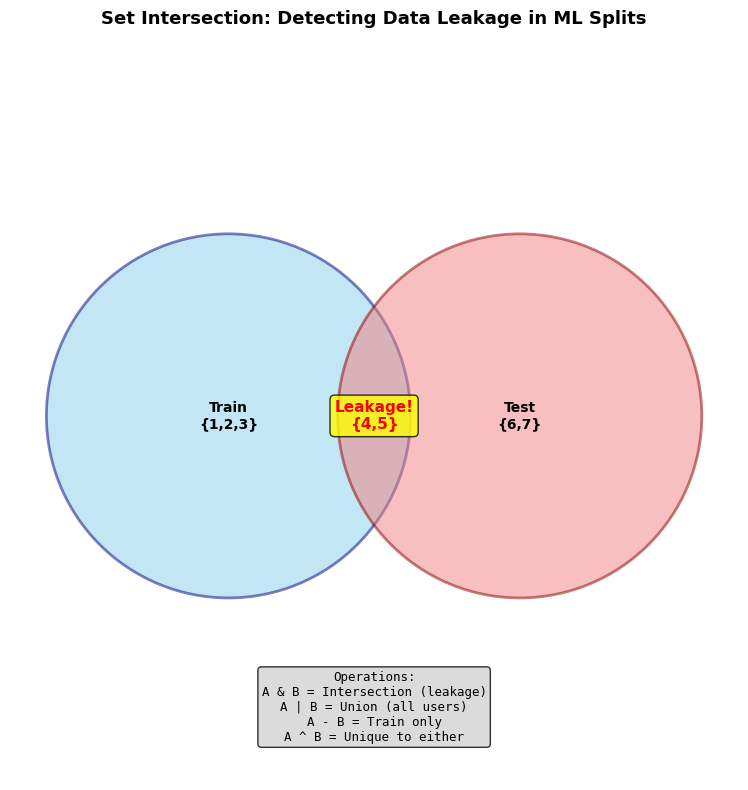

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 8))

# Create Venn diagram using circles
circle1 = patches.Circle((0.3, 0.5), 0.25, fill=True, 
                          facecolor='skyblue', edgecolor='navy', 
                          linewidth=2, alpha=0.5, label='Train Users')
circle2 = patches.Circle((0.7, 0.5), 0.25, fill=True, 
                          facecolor='lightcoral', edgecolor='darkred', 
                          linewidth=2, alpha=0.5, label='Test Users')

ax.add_patch(circle1)
ax.add_patch(circle2)

# Add labels
ax.text(0.3, 0.5, 'Train\n{1,2,3}', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(0.7, 0.5, 'Test\n{6,7}', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(0.5, 0.5, 'Leakage!\n{4,5}', ha='center', va='center', 
        fontsize=11, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Set Intersection: Detecting Data Leakage in ML Splits', 
             fontsize=13, fontweight='bold', pad=20)

# Add legend for operations
legend_text = "Operations:\nA & B = Intersection (leakage)\nA | B = Union (all users)\nA - B = Train only\nA ^ B = Unique to either"
ax.text(0.5, 0.05, legend_text, ha='center', va='bottom', 
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()



This visualization shows why set operations are critical for data validation. The overlapping region (intersection) represents users appearing in both splits—a red flag for any ML practitioner. The symmetric difference (users unique to either split) represents your truly independent test set. In production ML pipelines, these checks run automatically before model training begins, preventing expensive training runs on contaminated data.


### Frozenset: Immutable Sets


When you need set-like behavior but immutability (for use as dictionary keys or elements of other sets), use `frozenset`. Unlike regular sets, frozensets are hashable and cannot be modified after creation.

This is useful when you want to use a collection of items as a dictionary key—perhaps caching results based on a set of hyperparameters, or grouping data by immutable feature combinations.



In [7]:
# Frozenset for immutable collections
feature_combination = frozenset(['age', 'income', 'location'])

# Can be used as dictionary key
cache = {}
cache[feature_combination] = {'accuracy': 0.92, 'f1': 0.89}

# Another combination
another_combo = frozenset(['age', 'location'])
cache[another_combo] = {'accuracy': 0.85, 'f1': 0.82}

print(f"Cached results for {len(cache)} feature combinations:")
for features, metrics in cache.items():
    print(f"  Features {set(features)}: {metrics}")

# Cannot modify frozenset
try:
    feature_combination.add('gender')
except AttributeError as e:
    print(f"\nError (expected): Cannot modify frozenset - {e}")

Cached results for 2 feature combinations:
  Features {'income', 'age', 'location'}: {'accuracy': 0.92, 'f1': 0.89}
  Features {'age', 'location'}: {'accuracy': 0.85, 'f1': 0.82}

Error (expected): Cannot modify frozenset - 'frozenset' object has no attribute 'add'


## Dictionaries: Key-Value Mappings


Dictionaries are Python's most important data structure—unordered (insertion-ordered in Python 3.7+), mutable mappings from keys to values. In AI/ML, dictionaries are ubiquitous: model configurations, label encodings, feature dictionaries, JSON API responses, and parameter storage. With O(1) average-case lookup, they're optimized for fast access by key.

Understanding dictionary methods and patterns is essential for manipulating the structured data that flows through every ML pipeline. From hyperparameter grids to batch normalization statistics, dictionaries organize the complexity of modern AI systems.



In [8]:
# Creating dictionaries: multiple syntaxes
config = {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}
model_params = dict(hidden_dim=256, dropout=0.3, activation='relu')

# Accessing values
print(f"Learning rate: {config['learning_rate']}")
print(f"Safe access: {config.get('optimizer', 'adam')}")  # Default if missing

# Updating configurations
config.update({'optimizer': 'adam', 'weight_decay': 0.01})
config['epochs'] = 50  # Modify existing
print(f"Updated config: {config}")

# Dictionary views: dynamic reflections of data
print(f"\nKeys: {list(config.keys())}")
print(f"Values: {list(config.values())}")

# Items for iteration: most common pattern!
print("\nConfiguration summary:")
for key, value in config.items():
    print(f"  {key:15} = {value}")

# Dictionary comprehension: feature scaling parameters
features = ['height', 'width', 'depth']
scalers = {f: {'min': 0.0, 'max': 1.0} for f in features}
print(f"\nScaling config: {scalers}")

# Nested dictionaries: complex model architecture
architecture = {
    'input': {'shape': (224, 224, 3), 'dtype': 'float32'},
    'backbone': {'type': 'resnet50', 'pretrained': True},
    'head': {'type': 'classifier', 'num_classes': 10}
}
print(f"\nInput shape: {architecture['input']['shape']}")

Learning rate: 0.001
Safe access: adam
Updated config: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'optimizer': 'adam', 'weight_decay': 0.01}

Keys: ['learning_rate', 'batch_size', 'epochs', 'optimizer', 'weight_decay']
Values: [0.001, 32, 50, 'adam', 0.01]

Configuration summary:
  learning_rate   = 0.001
  batch_size      = 32
  epochs          = 50
  optimizer       = adam
  weight_decay    = 0.01

Scaling config: {'height': {'min': 0.0, 'max': 1.0}, 'width': {'min': 0.0, 'max': 1.0}, 'depth': {'min': 0.0, 'max': 1.0}}

Input shape: (224, 224, 3)


## Iteration Patterns for ML


Efficient iteration over collections is a core ML skill. You'll constantly pair elements from multiple lists (features and labels), track indices during processing, and build mappings from data. Python provides elegant tools for these patterns: `enumerate()` for index-value pairs, `zip()` for parallel iteration, and `collections.defaultdict` for automatic key initialization.

Mastering these patterns eliminates verbose index-tracking code and prevents off-by-one errors common in data preprocessing. These are the idioms that separate Pythonic ML code from verbose, error-prone alternatives.



In [9]:
from collections import defaultdict

# enumerate(): tracking sample indices during processing
filenames = ['img_001.jpg', 'img_002.jpg', 'img_003.jpg']
print("Processing with indices:")
for idx, fname in enumerate(filenames, start=1):  # Start at 1, not 0
    print(f"  Sample {idx}/{len(filenames)}: Loading {fname}")

# zip(): pairing features with labels and predictions
features = [[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]
labels = [0, 1, 0]
predictions = [0, 1, 1]

print("\nBatch analysis:")
correct = 0
for feat, label, pred in zip(features, labels, predictions):
    match = "✓" if label == pred else "✗"
    if label == pred:
        correct += 1
    print(f"  Features {feat} → True: {label}, Pred: {pred} {match}")

print(f"Batch accuracy: {correct}/{len(labels)} = {correct/len(labels):.1%}")

# defaultdict: grouping data without KeyError checks
# Group samples by class label
samples_by_class = defaultdict(list)
samples = [
    {'id': 1, 'label': 'cat', 'features': [0.1, 0.2]},
    {'id': 2, 'label': 'dog', 'features': [0.3, 0.4]},
    {'id': 3, 'label': 'cat', 'features': [0.5, 0.6]},
]

for sample in samples:
    label = sample['label']
    samples_by_class[label].append(sample['id'])

print(f"\nSamples grouped by class: {dict(samples_by_class)}")

# zip with * unpacking: transposing data (rows ↔ columns)
batch_data = [
    [1, 2, 3],  # Sample 1 features
    [4, 5, 6],  # Sample 2 features
    [7, 8, 9]   # Sample 3 features
]
# Transpose to get features by dimension
feature_dims = list(zip(*batch_data))
print(f"\nFeature 1 across samples: {feature_dims[0]}")
print(f"Feature 2 across samples: {feature_dims[1]}")
print(f"Feature 3 across samples: {feature_dims[2]}")

Processing with indices:
  Sample 1/3: Loading img_001.jpg
  Sample 2/3: Loading img_002.jpg
  Sample 3/3: Loading img_003.jpg

Batch analysis:
  Features [0.1, 0.2] → True: 0, Pred: 0 ✓
  Features [0.3, 0.4] → True: 1, Pred: 1 ✓
  Features [0.5, 0.6] → True: 0, Pred: 1 ✗
Batch accuracy: 2/3 = 66.7%

Samples grouped by class: {'cat': [1, 3], 'dog': [2]}

Feature 1 across samples: (1, 4, 7)
Feature 2 across samples: (2, 5, 8)
Feature 3 across samples: (3, 6, 9)


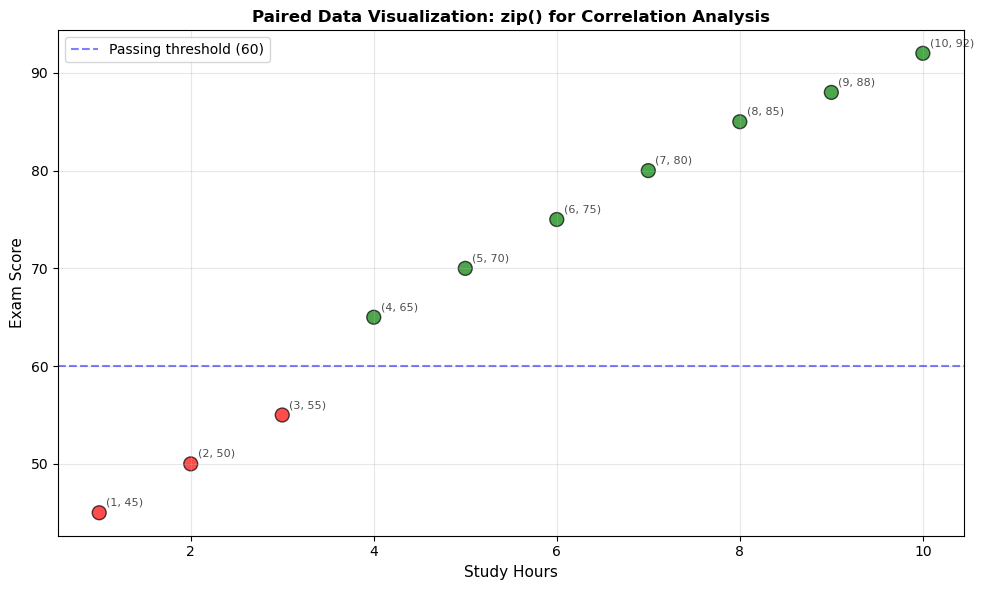

Correlation between study hours and scores: 0.993


In [10]:
import matplotlib.pyplot as plt

# Simulate paired data: study time vs exam scores
study_hours = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
exam_scores = [45, 50, 55, 65, 70, 75, 80, 85, 88, 92]
passed = [s >= 60 for s in exam_scores]  # Boolean list

# Color by pass/fail
colors = ['green' if p else 'red' for p in passed]

plt.figure(figsize=(10, 6))
plt.scatter(study_hours, exam_scores, c=colors, s=100, alpha=0.7, edgecolors='black')
plt.axhline(y=60, color='blue', linestyle='--', alpha=0.5, label='Passing threshold (60)')
plt.xlabel('Study Hours', fontsize=11)
plt.ylabel('Exam Score', fontsize=11)
plt.title('Paired Data Visualization: zip() for Correlation Analysis', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Add annotations
for hours, score in zip(study_hours, exam_scores):
    plt.annotate(f'({hours}, {score})', (hours, score), 
                textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Calculate correlation using zip
def correlation(x, y):
    n = len(x)
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    numerator = sum((xi - mean_x) * (yi - mean_y) for xi, yi in zip(x, y))
    denom_x = sum((xi - mean_x) ** 2 for xi in x) ** 0.5
    denom_y = sum((yi - mean_y) ** 2 for yi in y) ** 0.5
    return numerator / (denom_x * denom_y)

print(f"Correlation between study hours and scores: {correlation(study_hours, exam_scores):.3f}")

## Real-World ML Patterns


Let's synthesize everything into the three most common data structure patterns in ML pipelines: **list of dictionaries** (row-oriented data), **dictionary of lists** (column-oriented data), and **sets** for tracking seen items. Understanding when to use each—and how to convert between them—is essential for efficient data manipulation.

Row-oriented (list of dicts) is intuitive for record-based processing—each sample is a self-contained dictionary. Column-oriented (dict of lists) is memory-efficient for numerical computing—each feature is a contiguous list ready for vectorized operations. Sets provide O(1) membership testing for deduplication and filtering.



In [11]:
# Pattern 1: List of dictionaries (row-oriented)
# Common in: JSON data, API responses, database records
dataset_rows = [
    {'id': 1, 'feature_a': 0.5, 'feature_b': 0.3, 'label': 'A'},
    {'id': 2, 'feature_a': 0.2, 'feature_b': 0.8, 'label': 'B'},
    {'id': 3, 'feature_a': 0.9, 'feature_b': 0.1, 'label': 'A'},
]

print("Row-oriented access (sample 1):")
print(f"  Sample 1: {dataset_rows[0]}")

# Extract all labels (requires iteration)
labels_from_rows = [row['label'] for row in dataset_rows]
print(f"  All labels: {labels_from_rows}")

# Pattern 2: Dictionary of lists (column-oriented)  
# Common in: pandas DataFrames, numpy arrays, batch processing
dataset_cols = {
    'id': [1, 2, 3],
    'feature_a': [0.5, 0.2, 0.9],
    'feature_b': [0.3, 0.8, 0.1],
    'label': ['A', 'B', 'A']
}

print("\nColumn-oriented access (all feature_a):")
print(f"  Feature A values: {dataset_cols['feature_a']}")

# Convert: rows → columns (common preprocessing step)
from collections import defaultdict
def rows_to_columns(rows):
    if not rows:
        return {}
    cols = defaultdict(list)
    for row in rows:
        for key, value in row.items():
            cols[key].append(value)
    return dict(cols)

dataset_cols_converted = rows_to_columns(dataset_rows)
print(f"\nConverted to columns: {dataset_cols_converted}")

# Pattern 3: Set for seen items (deduplication & tracking)
# Common in: removing duplicate samples, tracking processed IDs
seen_ids = set()
unique_samples = []

for sample in dataset_rows:
    sample_id = sample['id']
    if sample_id not in seen_ids:
        seen_ids.add(sample_id)
        unique_samples.append(sample)
    else:
        print(f"  Duplicate detected: ID {sample_id}")

print(f"\nUnique samples count: {len(unique_samples)}")

# Pattern 4: Tuple as shape/config keys
# Common in: caching results by tensor shape, grouping by config
results_cache = {}
configs = [
    ((224, 224, 3), 10),  # (input_shape, num_classes)
    ((224, 224, 3), 100),
    ((299, 299, 3), 10),
]

for shape, classes in configs:
    key = (shape, classes)  # Tuple as dict key
    # Simulate computation
    results_cache[key] = {'params': sum(shape) * classes, 'flops': shape[0] * classes}

print(f"\nCached results for {len(results_cache)} configurations:")
for config, result in results_cache.items():
    print(f"  Shape {config[0]}, classes {config[1]}: {result}")

Row-oriented access (sample 1):
  Sample 1: {'id': 1, 'feature_a': 0.5, 'feature_b': 0.3, 'label': 'A'}
  All labels: ['A', 'B', 'A']

Column-oriented access (all feature_a):
  Feature A values: [0.5, 0.2, 0.9]

Converted to columns: {'id': [1, 2, 3], 'feature_a': [0.5, 0.2, 0.9], 'feature_b': [0.3, 0.8, 0.1], 'label': ['A', 'B', 'A']}

Unique samples count: 3

Cached results for 3 configurations:
  Shape (224, 224, 3), classes 10: {'params': 4510, 'flops': 2240}
  Shape (224, 224, 3), classes 100: {'params': 45100, 'flops': 22400}
  Shape (299, 299, 3), classes 10: {'params': 6010, 'flops': 2990}


# 🛠️ Hands-On Exercises


## 🛠️ Hands-On Exercises

Apply these data structures to realistic ML scenarios. Each exercise builds practical skills you'll use daily.

### Exercise 1: List Slicing for Train/Test Split
Given a list of 100 samples, create training (first 80%) and testing (last 20%) splits using slicing. Do not use scikit-learn—practice pure Python slicing.



In [12]:
# Your code here

samples = list(range(100))  # Represents 100 data samples
# TODO: Create train_samples (first 80%) and test_samples (last 20%)

train_samples = []
test_samples = []

print(f"Training set size: {len(train_samples)}")
print(f"Test set size: {len(test_samples)}")
print(f"First 3 train: {train_samples[:3]}, Last 3 test: {test_samples[-3:]}")

Training set size: 0
Test set size: 0
First 3 train: [], Last 3 test: []




**Hint**: Calculate 80% of 100, then use `[:split_idx]` and `[split_idx:]`.

---

### Exercise 2: List Methods for Batch Management
You have a list of batch losses. Add a new loss, remove the oldest (first) if there are more than 10, and calculate the moving average of the last 5.



In [13]:
# Your code here

loss_history = [0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.58, 0.55, 0.53]
new_loss = 0.52

# TODO: Append new_loss, keep only last 10, calculate mean of last 5

moving_average = 0
print(f"Updated history length: {len(loss_history)}")
print(f"Moving average (last 5): {moving_average:.3f}")

Updated history length: 9
Moving average (last 5): 0.000




---

### Exercise 3: Tuple Unpacking for Model Evaluation
A function returns `(loss, accuracy, precision, recall)` as a tuple. Unpack it into separate variables, and use extended unpacking to capture all metrics except loss.



In [14]:
# Your code here

def evaluate_model():
    return (0.34, 0.89, 0.85, 0.92)  # loss, acc, prec, rec

# TODO: Unpack into loss, accuracy, precision, recall
# TODO: Also unpack so 'rest' contains [accuracy, precision, recall] using *

loss = accuracy = precision = recall = 0
rest = []

print(f"Loss: {loss}, Other metrics: {rest}")

Loss: 0, Other metrics: []




---

### Exercise 4: Set Operations for Vocabulary
You have two text documents as lists of words. Find: (a) unique words in document 1, (b) words common to both, (c) words in either but not both.



In [15]:
# Your code here

doc1 = ['the', 'cat', 'sat', 'on', 'the', 'mat']
doc2 = ['the', 'dog', 'sat', 'on', 'the', 'log']

# TODO: Convert to sets and perform operations

unique_doc1 = set()
common = set()
symmetric_diff = set()

print(f"Unique to doc1: {unique_doc1}")
print(f"Common words: {common}")
print(f"In either but not both: {symmetric_diff}")

Unique to doc1: set()
Common words: set()
In either but not both: set()




---

### Exercise 5: Set Deduplication with Confidence
Filter a list of predictions to keep only unique class labels with highest confidence (if duplicate labels, keep highest confidence).



In [16]:
# Your code here

predictions = [
    ('cat', 0.7),
    ('dog', 0.8),
    ('cat', 0.9),  # Better cat, should replace first
    ('bird', 0.6),
    ('dog', 0.5),  # Worse dog, ignore
]

# TODO: Create dict mapping label → max confidence, then convert to set of (label, conf) tuples

best_predictions = set()
print(f"Best predictions: {sorted(best_predictions)}")
# Expected: {('bird', 0.6), ('cat', 0.9), ('dog', 0.8)}

Best predictions: []




---

### Exercise 6: Dictionary Building from Lists
Create a dictionary mapping class names to their indices from two parallel lists. Handle case where class name might not exist by returning -1.



In [17]:
# Your code here

class_names = ['background', 'person', 'car', 'tree']
indices = [0, 1, 2, 3]

# TODO: Create name_to_index dictionary
# TODO: Write function get_index(name) that returns index or -1

name_to_index = {}
def get_index(name):
    return -1

print(f"Dictionary: {name_to_index}")
print(f"Index of 'car': {get_index('car')}")
print(f"Index of 'bike': {get_index('bike')}")

Dictionary: {}
Index of 'car': -1
Index of 'bike': -1




---

### Exercise 7: Dictionary Comprehension for Feature Stats
Given a list of feature values, create a dictionary with statistics (min, max, mean) using dictionary comprehension.



In [18]:
# Your code here

features = [12.5, 15.2, 8.1, 22.3, 11.0, 19.5]

# TODO: Create stats dict with 'min', 'max', 'mean' keys
# Use min(), max(), sum()/len() functions

stats = {}
print(f"Feature statistics: {stats}")

Feature statistics: {}




---

### Exercise 8: enumerate and zip for Batch Processing
You have three lists: images, labels, predictions. Print a formatted string for each showing index, image name, true label, and whether prediction was correct.



In [19]:
# Your code here

images = ['img1.jpg', 'img2.jpg', 'img3.jpg', 'img4.jpg']
labels = ['cat', 'dog', 'cat', 'dog']
predictions = ['cat', 'dog', 'dog', 'dog']

# TODO: Use enumerate and zip to print formatted results
# Format: "[1/4] img1.jpg: true=cat, pred=cat ✓"




---

### Exercise 9: defaultdict for Grouping
Group a list of samples by their 'category' field using defaultdict. Count how many samples in each category.



In [20]:
# Your code here

from collections import defaultdict

samples = [
    {'id': 1, 'category': 'train'},
    {'id': 2, 'category': 'test'},
    {'id': 3, 'category': 'train'},
    {'id': 4, 'category': 'validation'},
    {'id': 5, 'category': 'test'},
]

# TODO: Group by category, count samples per category

grouped = defaultdict(list)
counts = {}

print(f"Grouped: {dict(grouped)}")
print(f"Counts: {counts}")

Grouped: {}
Counts: {}




---

### Exercise 10: Mixed Pattern Challenge
Convert row-oriented data (list of dicts) to column-oriented (dict of lists), then find the set of unique values in the 'label' column.



In [21]:
# Your code here

data = [
    {'feature': 0.5, 'label': 'A'},
    {'feature': 0.2, 'label': 'B'},
    {'feature': 0.9, 'label': 'A'},
    {'feature': 0.3, 'label': 'C'},
    {'feature': 0.7, 'label': 'B'},
]

# TODO: Convert to column-oriented
# TODO: Extract unique labels as set

columns = {}
unique_labels = set()

print(f"Columns: {columns}")
print(f"Unique labels: {unique_labels}")

Columns: {}
Unique labels: set()




---

### Exercise 11: Frozenset as Dictionary Key
Create a cache dictionary where keys are frozensets of features used, and values are model accuracy. Add two entries and retrieve one.



In [22]:
# Your code here

# TODO: Create cache with frozenset keys
# Key 1: frozenset(['age', 'income']), value: 0.85
# Key 2: frozenset(['age', 'location']), value: 0.82
# Retrieve accuracy for ['age', 'income'] (order shouldn't matter!)

cache = {}
accuracy = 0

print(f"Cache contents: {cache}")
print(f"Retrieved accuracy: {accuracy}")

Cache contents: {}
Retrieved accuracy: 0


# Solutions


## Solutions

### Exercise 1: List Slicing for Train/Test Split



In [23]:
samples = list(range(100))
split_idx = int(len(samples) * 0.8)

train_samples = samples[:split_idx]
test_samples = samples[split_idx:]

print(f"Training set size: {len(train_samples)}")  # Output: 80
print(f"Test set size: {len(test_samples)}")  # Output: 20
print(f"First 3 train: {train_samples[:3]}, Last 3 test: {test_samples[-3:]}")
# Output: First 3 train: [0, 1, 2], Last 3 test: [97, 98, 99]

Training set size: 80
Test set size: 20
First 3 train: [0, 1, 2], Last 3 test: [97, 98, 99]




---

### Exercise 2: List Methods for Batch Management



In [24]:
loss_history = [0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.58, 0.55, 0.53]
new_loss = 0.52

# Add new loss
loss_history.append(new_loss)

# Keep only last 10 (remove oldest if needed)
if len(loss_history) > 10:
    loss_history.pop(0)  # Remove first element

# Calculate moving average of last 5
last_5 = loss_history[-5:]
moving_average = sum(last_5) / len(last_5)

print(f"Updated history length: {len(loss_history)}")  # Output: 10
print(f"Moving average (last 5): {moving_average:.3f}")  # Output: 0.556

Updated history length: 10
Moving average (last 5): 0.556




---

### Exercise 3: Tuple Unpacking for Model Evaluation



In [25]:
def evaluate_model():
    return (0.34, 0.89, 0.85, 0.92)

# Standard unpacking
loss, accuracy, precision, recall = evaluate_model()

# Extended unpacking
loss, *rest = evaluate_model()

print(f"Loss: {loss}, Other metrics: {rest}")
# Output: Loss: 0.34, Other metrics: [0.89, 0.85, 0.92]

Loss: 0.34, Other metrics: [0.89, 0.85, 0.92]




---

### Exercise 4: Set Operations for Vocabulary



In [26]:
doc1 = ['the', 'cat', 'sat', 'on', 'the', 'mat']
doc2 = ['the', 'dog', 'sat', 'on', 'the', 'log']

set1 = set(doc1)
set2 = set(doc2)

unique_doc1 = set1 - set2  # Words only in doc1
common = set1 & set2  # Intersection
symmetric_diff = set1 ^ set2  # Symmetric difference

print(f"Unique to doc1: {unique_doc1}")  # Output: {'mat', 'cat'}
print(f"Common words: {common}")  # Output: {'on', 'sat', 'the'}
print(f"In either but not both: {symmetric_diff}")  # Output: {'log', 'mat', 'cat', 'dog'}

Unique to doc1: {'mat', 'cat'}
Common words: {'on', 'sat', 'the'}
In either but not both: {'log', 'cat', 'dog', 'mat'}




---

### Exercise 5: Set Deduplication with Confidence



In [27]:
predictions = [
    ('cat', 0.7),
    ('dog', 0.8),
    ('cat', 0.9),
    ('bird', 0.6),
    ('dog', 0.5),
]

# Keep max confidence per label
best = {}
for label, conf in predictions:
    if label not in best or conf > best[label]:
        best[label] = conf

# Convert to set of tuples
best_predictions = set(best.items())

print(f"Best predictions: {sorted(best_predictions)}")
# Output: Best predictions: [('bird', 0.6), ('cat', 0.9), ('dog', 0.8)]

Best predictions: [('bird', 0.6), ('cat', 0.9), ('dog', 0.8)]




---

### Exercise 6: Dictionary Building from Lists



In [28]:
class_names = ['background', 'person', 'car', 'tree']
indices = [0, 1, 2, 3]

# Create mapping
name_to_index = {name: idx for name, idx in zip(class_names, indices)}

def get_index(name):
    return name_to_index.get(name, -1)

print(f"Dictionary: {name_to_index}")
# Output: {'background': 0, 'person': 1, 'car': 2, 'tree': 3}

print(f"Index of 'car': {get_index('car')}")  # Output: 2
print(f"Index of 'bike': {get_index('bike')}")  # Output: -1

Dictionary: {'background': 0, 'person': 1, 'car': 2, 'tree': 3}
Index of 'car': 2
Index of 'bike': -1




---

### Exercise 7: Dictionary Comprehension for Feature Stats



In [29]:
features = [12.5, 15.2, 8.1, 22.3, 11.0, 19.5]

stats = {
    'min': min(features),
    'max': max(features),
    'mean': sum(features) / len(features)
}

print(f"Feature statistics: {stats}")
# Output: {'min': 8.1, 'max': 22.3, 'mean': 14.766666...}

Feature statistics: {'min': 8.1, 'max': 22.3, 'mean': 14.766666666666666}




---

### Exercise 8: enumerate and zip for Batch Processing



In [30]:
images = ['img1.jpg', 'img2.jpg', 'img3.jpg', 'img4.jpg']
labels = ['cat', 'dog', 'cat', 'dog']
predictions = ['cat', 'dog', 'dog', 'dog']

total = len(images)
for idx, (img, label, pred) in enumerate(zip(images, labels, predictions), 1):
    correct = "✓" if label == pred else "✗"
    print(f"[{idx}/{total}] {img}: true={label}, pred={pred} {correct}")

# Output:
# [1/4] img1.jpg: true=cat, pred=cat ✓
# [2/4] img2.jpg: true=dog, pred=dog ✓
# [3/4] img3.jpg: true=cat, pred=dog ✗
# [4/4] img4.jpg: true=dog, pred=dog ✓

[1/4] img1.jpg: true=cat, pred=cat ✓
[2/4] img2.jpg: true=dog, pred=dog ✓
[3/4] img3.jpg: true=cat, pred=dog ✗
[4/4] img4.jpg: true=dog, pred=dog ✓




---

### Exercise 9: defaultdict for Grouping



In [31]:
from collections import defaultdict

samples = [
    {'id': 1, 'category': 'train'},
    {'id': 2, 'category': 'test'},
    {'id': 3, 'category': 'train'},
    {'id': 4, 'category': 'validation'},
    {'id': 5, 'category': 'test'},
]

grouped = defaultdict(list)
for sample in samples:
    grouped[sample['category']].append(sample['id'])

counts = {cat: len(ids) for cat, ids in grouped.items()}

print(f"Grouped: {dict(grouped)}")
# Output: {'train': [1, 3], 'test': [2, 5], 'validation': [4]}

print(f"Counts: {counts}")
# Output: {'train': 2, 'test': 2, 'validation': 1}

Grouped: {'train': [1, 3], 'test': [2, 5], 'validation': [4]}
Counts: {'train': 2, 'test': 2, 'validation': 1}




---

### Exercise 10: Mixed Pattern Challenge



In [32]:
data = [
    {'feature': 0.5, 'label': 'A'},
    {'feature': 0.2, 'label': 'B'},
    {'feature': 0.9, 'label': 'A'},
    {'feature': 0.3, 'label': 'C'},
    {'feature': 0.7, 'label': 'B'},
]

# Convert to columns
columns = defaultdict(list)
for row in data:
    for key, value in row.items():
        columns[key].append(value)

columns = dict(columns)
unique_labels = set(columns['label'])

print(f"Columns: {columns}")
# Output: {'feature': [0.5, 0.2, 0.9, 0.3, 0.7], 'label': ['A', 'B', 'A', 'C', 'B']}

print(f"Unique labels: {unique_labels}")
# Output: {'A', 'B', 'C'}

Columns: {'feature': [0.5, 0.2, 0.9, 0.3, 0.7], 'label': ['A', 'B', 'A', 'C', 'B']}
Unique labels: {'A', 'B', 'C'}




---

### Exercise 11: Frozenset as Dictionary Key



In [33]:
# Create cache with frozenset keys
cache = {
    frozenset(['age', 'income']): 0.85,
    frozenset(['age', 'location']): 0.82
}

# Retrieve using frozenset (order doesn't matter!)
query = frozenset(['income', 'age'])  # Different order
accuracy = cache.get(query, 0.0)

print(f"Cache contents: {cache}")
# Output: {frozenset({'age', 'income'}): 0.85, frozenset({'age', 'location'}): 0.82}

print(f"Retrieved accuracy: {accuracy}")
# Output: 0.85

Cache contents: {frozenset({'income', 'age'}): 0.85, frozenset({'age', 'location'}): 0.82}
Retrieved accuracy: 0.85
